In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
#dataset loaded
df=pd.read_csv('Social_Network_Ads.csv')
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [3]:
#separating independent & dependent variables
X=df.iloc[:, :-1].values
y=df.iloc[:, -1].values

In [4]:
#splitting train & test data
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
#scaling features
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [6]:
#training model
regr=RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=42)
regr.fit(X_train_scaled, y_train)

,n_estimators,10
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
#prediction 
y_pred=regr.predict(X_test_scaled)
print(y_pred)

[1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 1 0 0 1 1 0 1 0 0 0 1 0 1 0 0
 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 1 1 0 1 1 0 0 0
 1 0 1 1 0 0]


In [8]:
proba=regr.predict_proba(X_test_scaled)
print(proba)

[[0.   1.  ]
 [0.5  0.5 ]
 [1.   0.  ]
 [0.5  0.5 ]
 [1.   0.  ]
 [1.   0.  ]
 [0.1  0.9 ]
 [1.   0.  ]
 [0.8  0.2 ]
 [1.   0.  ]
 [1.   0.  ]
 [0.   1.  ]
 [1.   0.  ]
 [1.   0.  ]
 [0.9  0.1 ]
 [0.   1.  ]
 [0.1  0.9 ]
 [0.5  0.5 ]
 [1.   0.  ]
 [0.3  0.7 ]
 [1.   0.  ]
 [1.   0.  ]
 [0.   1.  ]
 [0.7  0.3 ]
 [1.   0.  ]
 [0.   1.  ]
 [0.2  0.8 ]
 [1.   0.  ]
 [0.   1.  ]
 [1.   0.  ]
 [0.6  0.4 ]
 [0.8  0.2 ]
 [0.   1.  ]
 [1.   0.  ]
 [0.1  0.9 ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [0.   1.  ]
 [1.   0.  ]
 [1.   0.  ]
 [0.   1.  ]
 [1.   0.  ]
 [0.4  0.6 ]
 [1.   0.  ]
 [1.   0.  ]
 [0.5  0.5 ]
 [1.   0.  ]
 [1.   0.  ]
 [0.3  0.7 ]
 [1.   0.  ]
 [1.   0.  ]
 [0.7  0.3 ]
 [1.   0.  ]
 [0.   1.  ]
 [0.4  0.6 ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [0.2  0.8 ]
 [0.9  0.1 ]
 [1.   0.  ]
 [0.3  0.7 ]
 [0.2  0.8 ]
 [0.3  0.7 ]
 [1.   0.  ]
 [0.35 0.65]
 [0.4  0.6 ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [0.   1.  ]
 [1.   0.  ]
 [0.3  0.7 ]

In [9]:
accuracy=accuracy_score(y_test, y_pred)
accuracy

0.8625

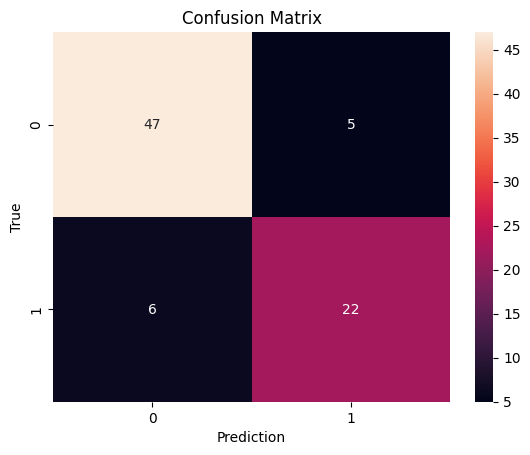

In [10]:
confusion=confusion_matrix(y_test, y_pred)
sns.heatmap(confusion, annot=True)
plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('random_forest_conf_matrix.png')
plt.show()

In [11]:
regr.predict([[27, 80000]])

array([1])

C:\Users\User\AppData\Local\Temp\ipykernel_4484\2555538976.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


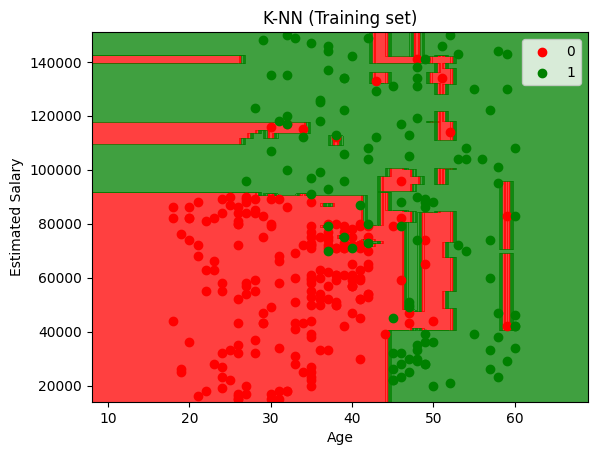

In [13]:
# Visualising the Training set results
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train_scaled), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1), np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
plt.contourf(X1, X2, regr.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('K-NN (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.savefig('random_forest_pred-plot.png')
plt.show()